# 📈 Fase 1: Ingeniería de Features y Modelado de Volatilidad (Mundo $P$)
### Finanzas Cuantitativas, la Ciencia y los Mercados — FCEN / UBA

Este notebook audita y valida los modelos econométricos y cuantitativos construidos en la **Fase 1** del proyecto:
1. **Medición Ex-Post:** Estimadores de rango OHLC (*Garman-Klass*, *Yang-Zhang*, *Parkinson*) vs *Close-to-Close*.
2. **Predicción Ex-Ante:** Volatilidad condicional asimétrica **GJR-GARCH(1,1)** con *leverage effect* (Clase 4).
3. **Term-Structure VIX/VIX3M:** Cointegración dinámica vía **Filtro de Kalman** y reversión a la media con **Ornstein-Uhlenbeck** ($s$-score, Clase 7).
4. **CAPM Dinámico:** Evolución temporal de $\beta_{i, t}$ y riesgo idiosincrático $\sigma_\varepsilon$ vía Kalman 2D.
5. **Estacionariedad con Memoria:** Diferenciación Fraccionaria ($d^*$ óptimo, Clase 6).
6. **Variance Risk Premium (VRP):** Cosecha empírica de $\sigma_{impl} - \sigma_{real}$.

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo visual profesional
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Carga del dataset generado por el pipeline de la Fase 1
df = pd.read_parquet('../data/features_phase1.parquet')
print(f'Dataset cargado exitosamente: {df.shape[0]} ruedas x {df.shape[1]} features.')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
df.tail(3)

Dataset cargado exitosamente: 1636 ruedas x 55 features.
Rango temporal: 2020-03-30 a 2026-09-29


,rf_annual,rf_daily,vix_level,vix3m_level,vix_log_spread,vix_kalman_beta,vix_kalman_spread,ou_theta,ou_kappa,ou_half_life,...,NVDA_vol_yz_21d,NVDA_gjr_cond_vol,NVDA_kalman_alpha,NVDA_kalman_beta,NVDA_idiosyncratic_vol_21d,NVDA_fracdiff_dopt,NVDA_d_optimal,vrp_vix_minus_spy_gk,vrp_vix_minus_spy_garch,vrp_ratio_vix_garch
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-25,0.04070,0.000162,14.870000,17.93,-0.187130,0.943568,-0.025294,-0.164489,0.358554,1.933172,...,0.310416,0.380786,NaN,NaN,NaN,3.961854,0.7,0.076710,0.033916,1.295481
2026-09-28,0.04057,0.000161,16.070000,18.23,-0.126114,0.944116,0.037711,-0.164565,0.359238,1.929494,...,0.307468,0.370820,NaN,NaN,NaN,7.471125,0.7,0.089831,0.050489,1.458117
2026-09-29,0.04065,0.000161,16.040001,18.09,-0.120274,0.944717,0.041532,-0.162482,0.369348,1.876679,...,0.307526,0.364196,NaN,NaN,NaN,3.112829,0.7,0.089137,0.036701,1.296699


## 1. Medición de Volatilidad: Rango OHLC vs GJR-GARCH
Contrastamos la volatilidad realizada medida por **Garman-Klass (GK)** y **Yang-Zhang (YZ)** frente a la condicional predicha por **GJR-GARCH(1,1)** y la implícita cotizada por el **VIX**.

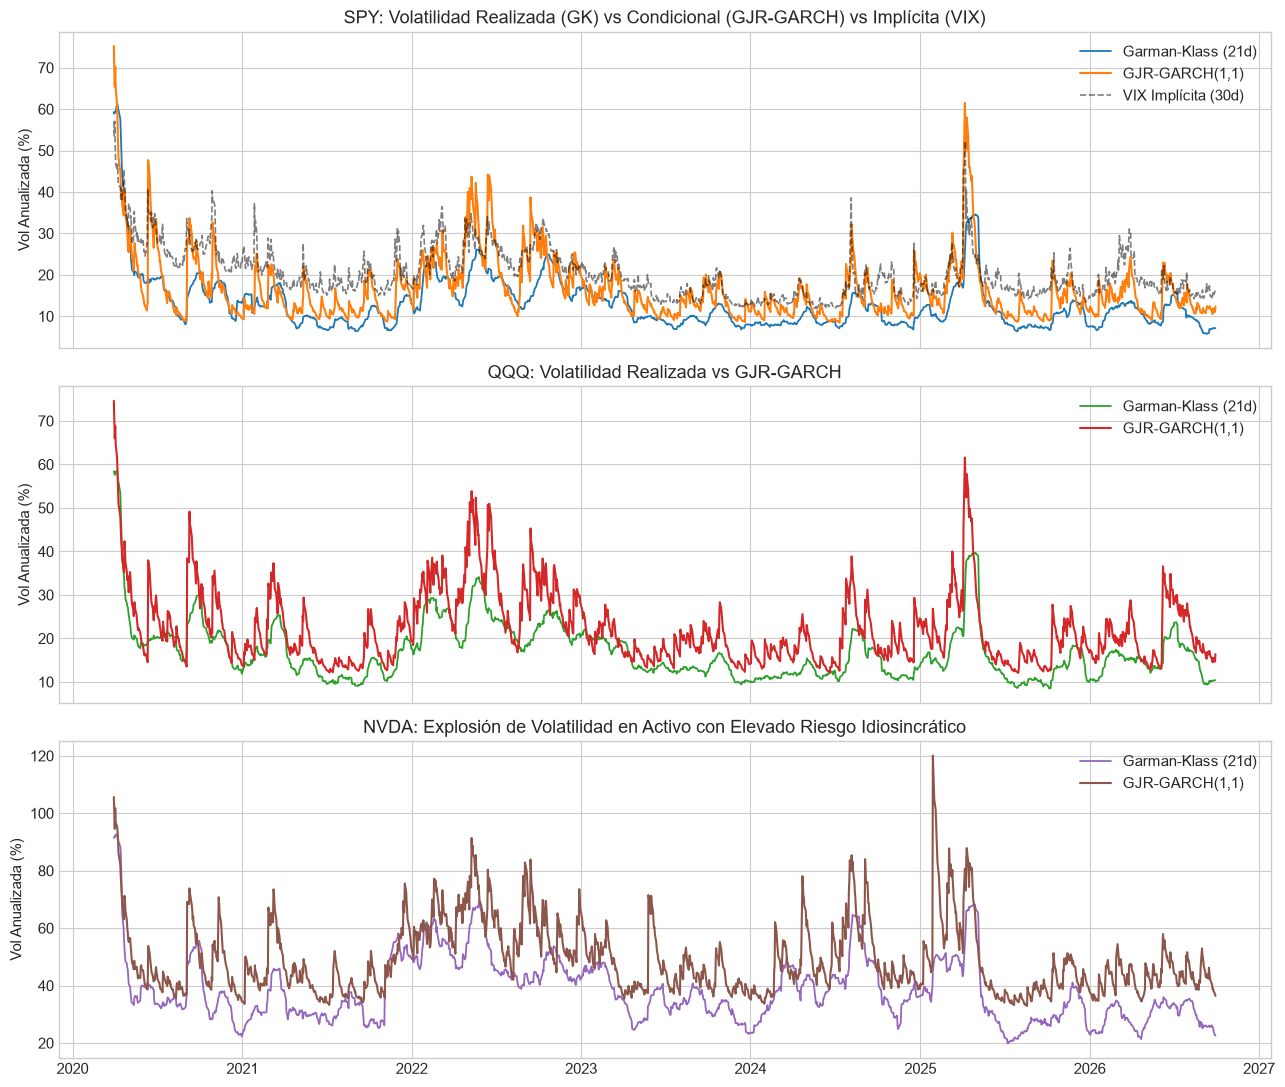

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# 1. SPY
axes[0].plot(df.index, df['SPY_vol_gk_21d'] * 100, label='Garman-Klass (21d)', color='#1f77b4', lw=1.3)
axes[0].plot(df.index, df['SPY_gjr_cond_vol'] * 100, label='GJR-GARCH(1,1)', color='#ff7f0e', lw=1.5)
axes[0].plot(df.index, df['vix_level'], label='VIX Implícita (30d)', color='black', alpha=0.5, ls='--', lw=1.2)
axes[0].set_title('SPY: Volatilidad Realizada (GK) vs Condicional (GJR-GARCH) vs Implícita (VIX)')
axes[0].set_ylabel('Vol Anualizada (%)')
axes[0].legend(loc='upper right')

# 2. QQQ
axes[1].plot(df.index, df['QQQ_vol_gk_21d'] * 100, label='Garman-Klass (21d)', color='#2ca02c', lw=1.3)
axes[1].plot(df.index, df['QQQ_gjr_cond_vol'] * 100, label='GJR-GARCH(1,1)', color='#d62728', lw=1.5)
axes[1].set_title('QQQ: Volatilidad Realizada vs GJR-GARCH')
axes[1].set_ylabel('Vol Anualizada (%)')
axes[1].legend(loc='upper right')

# 3. NVDA
axes[2].plot(df.index, df['NVDA_vol_gk_21d'] * 100, label='Garman-Klass (21d)', color='#9467bd', lw=1.3)
axes[2].plot(df.index, df['NVDA_gjr_cond_vol'] * 100, label='GJR-GARCH(1,1)', color='#8c564b', lw=1.5)
axes[2].set_title('NVDA: Explosión de Volatilidad en Activo con Elevado Riesgo Idiosincrático')
axes[2].set_ylabel('Vol Anualizada (%)')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 2. Term-Structure del VIX, Filtro de Kalman y Ornstein-Uhlenbeck (Clase 7)
Analizamos el spread $\ln(\text{VIX}) - \ln(\text{VIX3M})$, su hedge ratio dinámico vía Kalman y el $s$-score normalizado de reversión a la media.

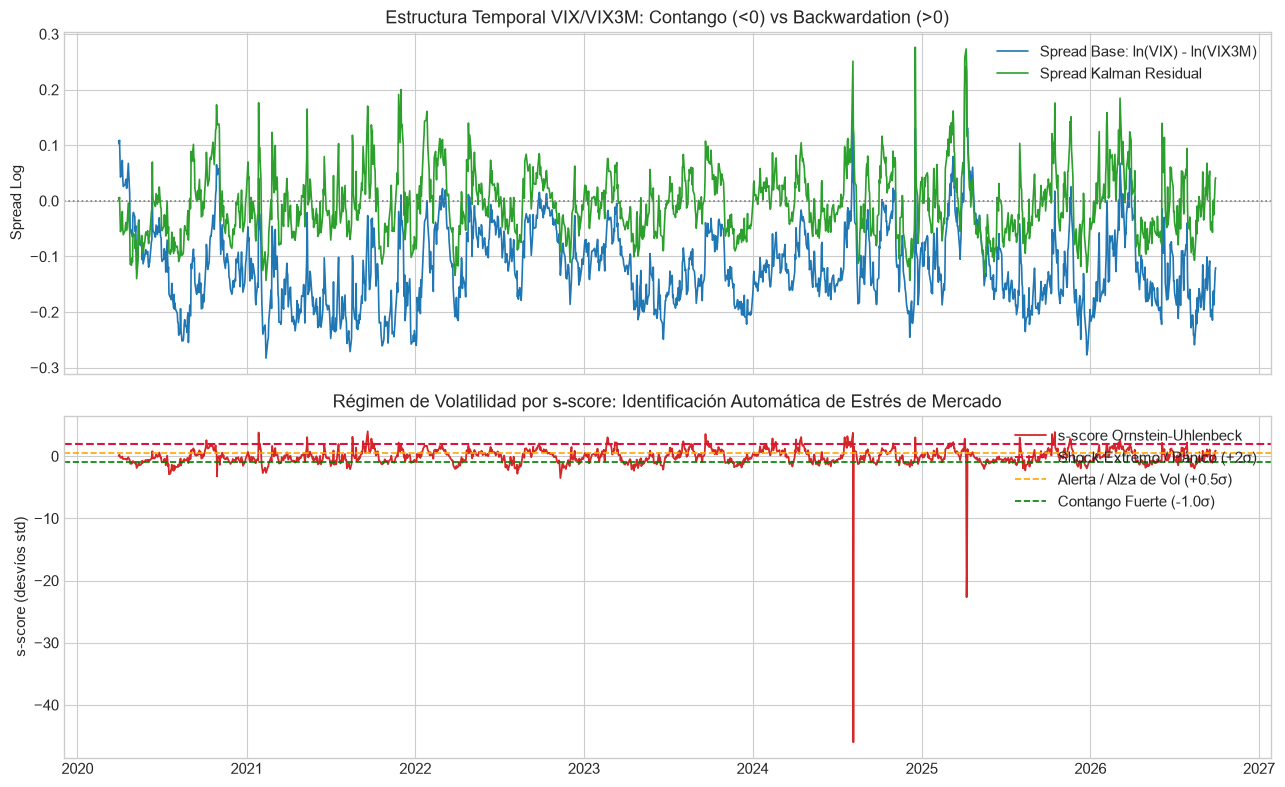

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Spread Base vs Kalman
ax1.plot(df.index, df['vix_log_spread'], label='Spread Base: ln(VIX) - ln(VIX3M)', color='#1f77b4', lw=1.2)
ax1.plot(df.index, df['vix_kalman_spread'], label='Spread Kalman Residual', color='#2ca02c', lw=1.2)
ax1.axhline(0, color='gray', ls=':', lw=1.2)
ax1.set_title('Estructura Temporal VIX/VIX3M: Contango (<0) vs Backwardation (>0)')
ax1.set_ylabel('Spread Log')
ax1.legend()

# s-score de Ornstein-Uhlenbeck y Regímenes
ax2.plot(df.index, df['ou_s_score'], label='s-score Ornstein-Uhlenbeck', color='#d62728', lw=1.3)
ax2.axhline(2.0, color='crimson', ls='--', lw=1.5, label='Shock Extremo / Pánico (+2σ)')
ax2.axhline(0.5, color='orange', ls='--', lw=1.2, label='Alerta / Alza de Vol (+0.5σ)')
ax2.axhline(-1.0, color='green', ls='--', lw=1.2, label='Contango Fuerte (-1.0σ)')
ax2.set_title('Régimen de Volatilidad por s-score: Identificación Automática de Estrés de Mercado')
ax2.set_ylabel('s-score (desvíos std)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. CAPM Dinámico con Filtro de Kalman (Clase 4 & 7)
Rastreamos el $\beta_t$ en tiempo real y el riesgo idiosincrático (desvío de los residuos de Kalman) para `NVDA` y `QQQ` frente al mercado (`SPY`).

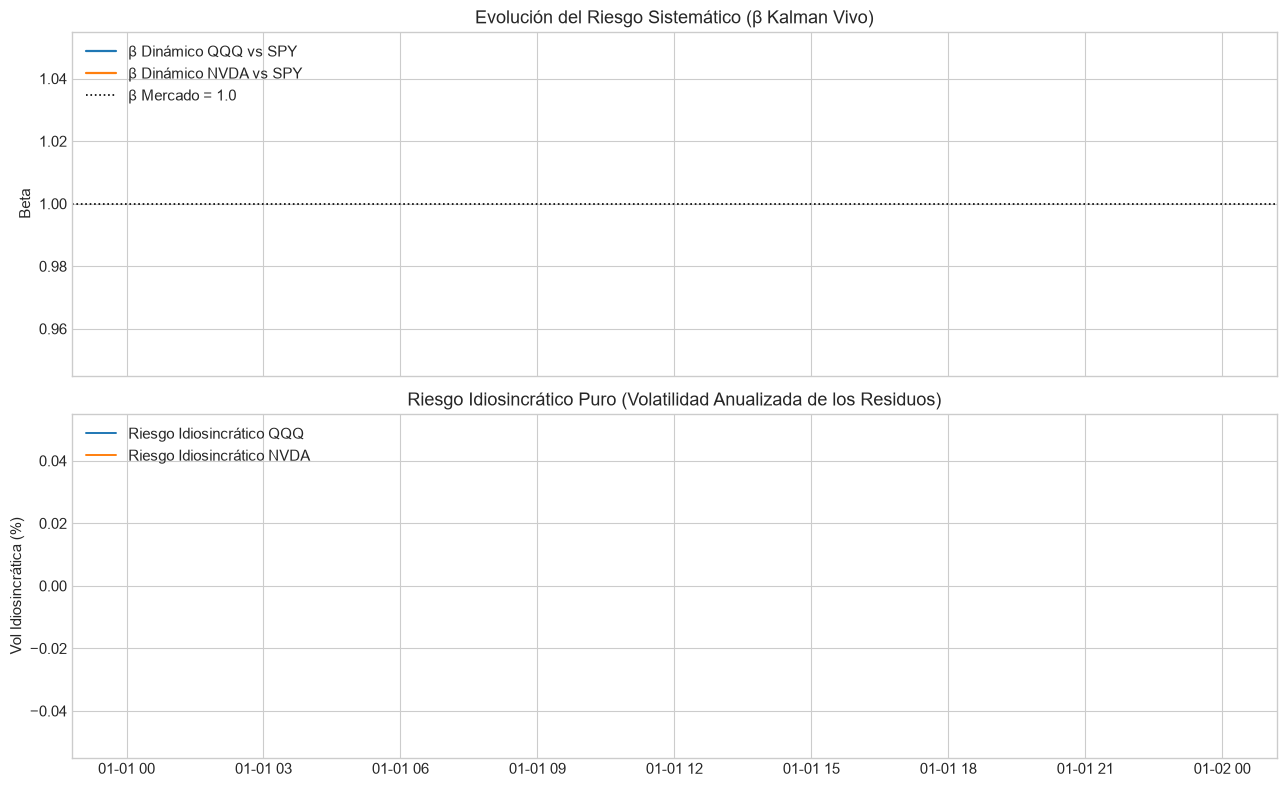

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Betas dinámicos
ax1.plot(df.index, df['QQQ_kalman_beta'], label='β Dinámico QQQ vs SPY', color='#1f77b4', lw=1.6)
ax1.plot(df.index, df['NVDA_kalman_beta'], label='β Dinámico NVDA vs SPY', color='#ff7f0e', lw=1.6)
ax1.axhline(1.0, color='black', ls=':', lw=1.2, label='β Mercado = 1.0')
ax1.set_title('Evolución del Riesgo Sistemático (β Kalman Vivo)')
ax1.set_ylabel('Beta')
ax1.legend(loc='upper left')

# Riesgo idiosincrático
ax2.plot(df.index, df['QQQ_idiosyncratic_vol_21d'] * 100, label='Riesgo Idiosincrático QQQ', color='#1f77b4', lw=1.4)
ax2.plot(df.index, df['NVDA_idiosyncratic_vol_21d'] * 100, label='Riesgo Idiosincrático NVDA', color='#ff7f0e', lw=1.4)
ax2.set_title('Riesgo Idiosincrático Puro (Volatilidad Anualizada de los Residuos)')
ax2.set_ylabel('Vol Idiosincrática (%)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 4. Variance Risk Premium (VRP): Implícita vs Realizada
Verificamos la hipótesis teórica central: $\text{VRP} = \sigma_{impl} - \sigma_{real} > 0$ en la gran mayoría del tiempo, justificando la venta sistemática de volatilidad condicionada.

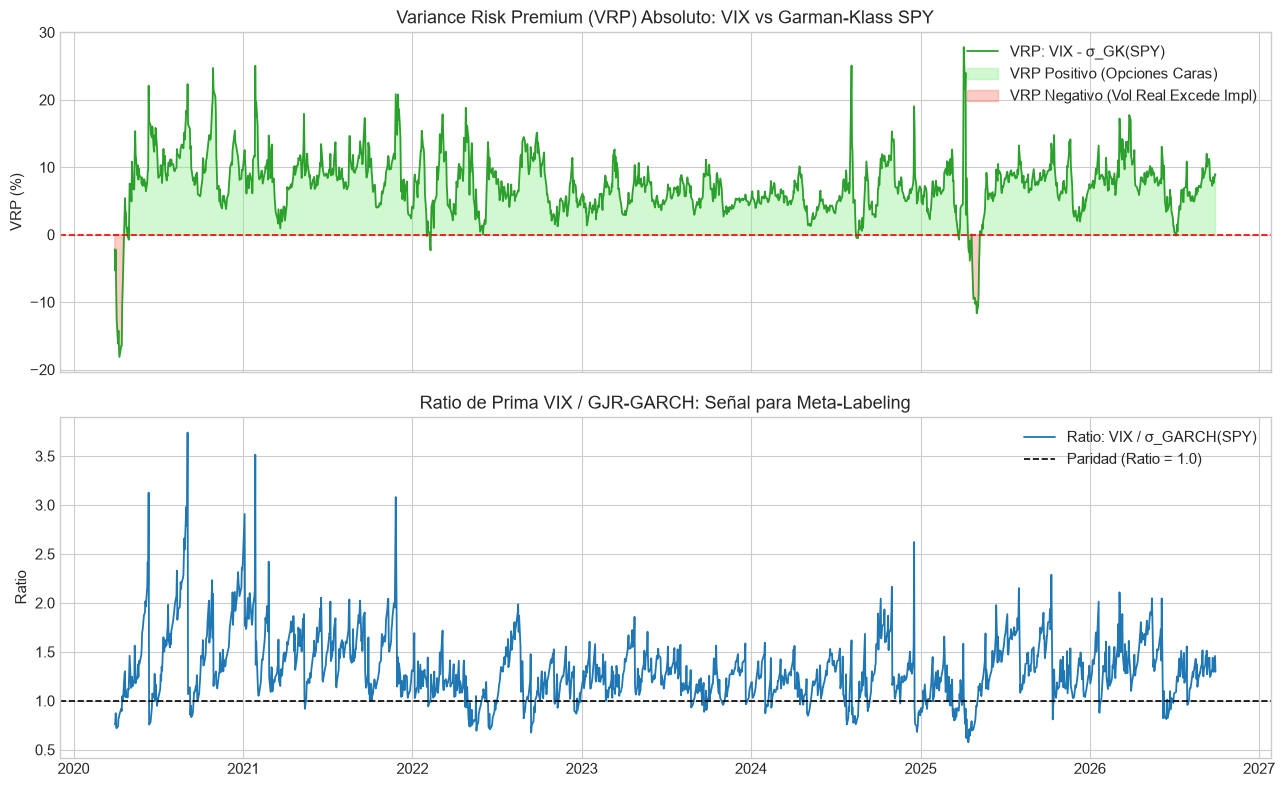

VRP promedio histórico: +7.30% anual
Porcentaje de ruedas con VRP positivo: 97.3%


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# VRP absoluto
ax1.plot(df.index, df['vrp_vix_minus_spy_gk'] * 100, label='VRP: VIX - σ_GK(SPY)', color='#2ca02c', lw=1.3)
ax1.axhline(0, color='red', ls='--', lw=1.2)
ax1.fill_between(df.index, df['vrp_vix_minus_spy_gk'] * 100, 0, where=(df['vrp_vix_minus_spy_gk'] >= 0), color='lightgreen', alpha=0.4, label='VRP Positivo (Opciones Caras)')
ax1.fill_between(df.index, df['vrp_vix_minus_spy_gk'] * 100, 0, where=(df['vrp_vix_minus_spy_gk'] < 0), color='salmon', alpha=0.4, label='VRP Negativo (Vol Real Excede Impl)')
ax1.set_title('Variance Risk Premium (VRP) Absoluto: VIX vs Garman-Klass SPY')
ax1.set_ylabel('VRP (%)')
ax1.legend(loc='upper right')

# Ratio VIX / GARCH
ax2.plot(df.index, df['vrp_ratio_vix_garch'], label='Ratio: VIX / σ_GARCH(SPY)', color='#1f77b4', lw=1.3)
ax2.axhline(1.0, color='black', ls='--', lw=1.2, label='Paridad (Ratio = 1.0)')
ax2.set_title('Ratio de Prima VIX / GJR-GARCH: Señal para Meta-Labeling')
ax2.set_ylabel('Ratio')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

vrp_mean = df['vrp_vix_minus_spy_gk'].mean() * 100
vrp_pos_pct = (df['vrp_vix_minus_spy_gk'] > 0).mean() * 100
print(f'VRP promedio histórico: +{vrp_mean:.2f}% anual')
print(f'Porcentaje de ruedas con VRP positivo: {vrp_pos_pct:.1f}%')

## 5. Diferenciación Fraccionaria: Memoria vs Estacionariedad
Comparamos la serie en niveles con su versión fraccionariamente diferenciada con $d^*$ óptimo para alimentar modelos supervisados de Machine Learning sin perder memoria histórica.

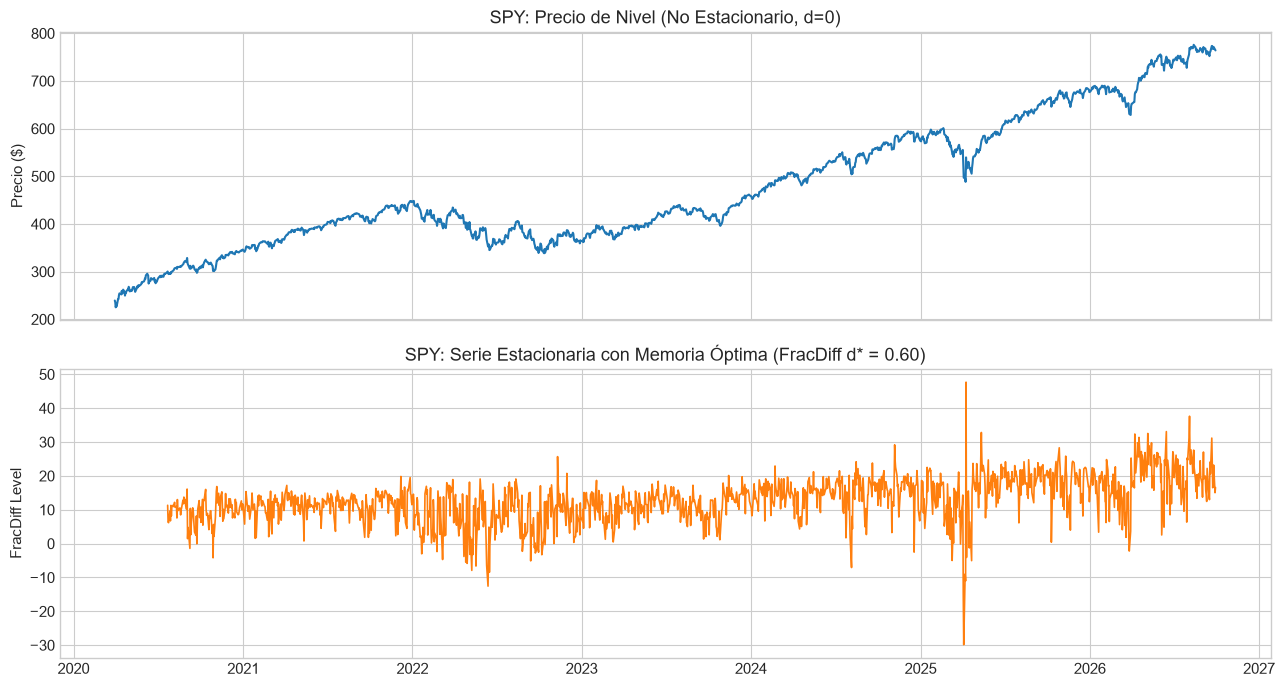

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(df.index, df['SPY_adj_close'], color='#1f77b4', lw=1.5)
ax1.set_title(f'SPY: Precio de Nivel (No Estacionario, d=0)')
ax1.set_ylabel('Precio ($)')

d_spy = df['SPY_d_optimal'].iloc[-1]
ax2.plot(df.index, df['SPY_fracdiff_dopt'], color='#ff7f0e', lw=1.2)
ax2.set_title(f'SPY: Serie Estacionaria con Memoria Óptima (FracDiff d* = {d_spy:.2f})')
ax2.set_ylabel('FracDiff Level')

plt.tight_layout()
plt.show()